In [1]:
!pip install -q -U git+https://github.com/huggingface/transformers
!pip install -q -U accelerate peft bitsandbytes qwen-vl-utils datasets trl sentencepiece
!pip install -q "pillow<12.0,>=10.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 56.8 MB/s eta 0:00:00


In [2]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

from qwen_vl_utils import process_vision_info

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

DATA_ROOT = Path("/kaggle/input/datasets/hoanggiabao3105/dataset")
QA_CSV = DATA_ROOT / "all_crops_spcqa_v4_similarity_safe_clean_merged.csv"
RAG_CSV = DATA_ROOT / "all_crops_rag_knowledge_standard_core.csv"

OUTPUT_DIR = Path("/kaggle/working/qwen25_vl_3b_agri_lora")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT, DATA_ROOT.exists())
print("QA_CSV:", QA_CSV, QA_CSV.exists())
print("RAG_CSV:", RAG_CSV, RAG_CSV.exists())

CUDA: True
GPU: Tesla T4
VRAM GB: 14.56317138671875
DATA_ROOT: /kaggle/input/datasets/hoanggiabao3105/dataset True
QA_CSV: /kaggle/input/datasets/hoanggiabao3105/dataset/all_crops_spcqa_v4_similarity_safe_clean_merged.csv True
RAG_CSV: /kaggle/input/datasets/hoanggiabao3105/dataset/all_crops_rag_knowledge_standard_core.csv True


In [3]:
qa_df = pd.read_csv(QA_CSV)

print("QA shape:", qa_df.shape)
print(qa_df.columns.tolist())

needed_cols = [
    "sample_id",
    "image_real_path",
    "image_path_masked",
    "crop",
    "canonical_label",
    "condition_group",
    "question",
    "visible_symptoms",
    "lesion_location",
    "symptom_pattern",
    "severity_level",
    "confidence_level",
    "triage_level",
    "image_quality",
]

existing_cols = [c for c in needed_cols if c in qa_df.columns]
qa_df = qa_df[existing_cols].copy()

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

print("\nMột vài image_real_path trong CSV:")
display(qa_df[["image_real_path", "crop", "canonical_label"]].head(10))

QA shape: (125120, 22)
['sample_id', 'image_id', 'image_path_masked', 'image_real_path', 'crop', 'canonical_label', 'condition_group', 'dataset_split', 'question_type', 'question', 'visible_symptoms', 'lesion_location', 'symptom_pattern', 'severity_level', 'image_quality', 'confidence_level', 'triage_level', 'label_mentioned_in_question', 'input_no_label', 'input_with_label', 'target_answer', 'linked_knowledge_ids']

Một vài image_real_path trong CSV:


,image_real_path,crop,canonical_label
0,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
1,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
2,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
3,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
4,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
5,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
6,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
7,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,cà chua,bệnh đốm vi khuẩn
8,Ca_chua/Tomato___Bacterial_spot/0a64655c-4052-...,cà chua,bệnh đốm vi khuẩn
9,Ca_chua/Tomato___Bacterial_spot/0a64655c-4052-...,cà chua,bệnh đốm vi khuẩn


In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_image_files = [
    p for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

print("Tổng ảnh thật tìm thấy trong DATA_ROOT:", len(all_image_files))
print("Ví dụ ảnh thật:")
for p in all_image_files[:10]:
    print(p)

from collections import defaultdict
from pathlib import PurePosixPath

index_by_parent_file = defaultdict(list)
index_by_filename = defaultdict(list)

for p in all_image_files:
    filename_key = p.name.lower()
    parent_key = p.parent.name.lower()

    index_by_parent_file[(parent_key, filename_key)].append(p)
    index_by_filename[filename_key].append(p)

crop_to_folder_keys = {
    "bí đỏ": ["Bi_do"],
    "cà chua": ["Ca_chua", "Ca_chua_filtered"],
    "dưa leo": ["Dua_leo", "Dua_leo_filtered"],
    "khổ qua/mướp đắng": ["Kho_qua"],
}

def path_contains_crop(p: Path, crop: str):
    keys = crop_to_folder_keys.get(crop, [])
    parts = set(p.parts)
    return any(k in parts for k in keys)

def clean_rel_parts(path_str):
    """
    Chuẩn hóa image_real_path.
    Nếu path là absolute hoặc có chứa dataset/... thì cắt về phần tương đối trong dataset.
    """
    raw = str(path_str).replace("\\", "/").strip()
    parts = list(PurePosixPath(raw).parts)

    # Bỏ dấu "/" nếu có
    parts = [x for x in parts if x not in ["/", ""]]

    # Nếu có đoạn .../dataset/xxx thì lấy sau dataset
    if "dataset" in parts:
        idx = parts.index("dataset")
        parts = parts[idx + 1:]

    return parts

def resolve_image_path_from_row(row):
    raw = safe_text(row.get("image_real_path", ""))
    crop = safe_text(row.get("crop", ""))

    if not raw:
        return None

    # Nếu raw là absolute path thật
    raw_path = Path(raw)
    if raw_path.exists():
        return str(raw_path)

    parts = clean_rel_parts(raw)

    if not parts:
        return None

    # Candidate trực tiếp
    candidates = []

    candidates.append(DATA_ROOT.joinpath(*parts))

    # Sửa các root hay gặp
    root = parts[0]

    if root == "Bi_do":
        # Kaggle thực tế của bạn có Bi_do/Bi_do/...
        candidates.append(DATA_ROOT.joinpath("Bi_do", "Bi_do", *parts[1:]))
        candidates.append(DATA_ROOT.joinpath("Bi_do", *parts[1:]))

    elif root == "Ca_chua":
        candidates.append(DATA_ROOT.joinpath("Ca_chua_filtered", *parts[1:]))
        candidates.append(DATA_ROOT.joinpath("Ca_chua", *parts[1:]))

    elif root == "Dua_leo":
        candidates.append(DATA_ROOT.joinpath("Dua_leo_filtered", *parts[1:]))
        candidates.append(DATA_ROOT.joinpath("Dua_leo", *parts[1:]))

    elif root == "Kho_qua":
        candidates.append(DATA_ROOT.joinpath("Kho_qua", *parts[1:]))
        candidates.append(DATA_ROOT.joinpath("Kho_qua", "Kho_qua", *parts[1:]))

    for p in candidates:
        if p.exists():
            return str(p)

    # Fallback: match theo disease folder + filename
    filename = parts[-1].lower()
    parent_folder = parts[-2].lower() if len(parts) >= 2 else ""

    matches = index_by_parent_file.get((parent_folder, filename), [])

    if len(matches) == 1:
        return str(matches[0])

    if len(matches) > 1:
        crop_matches = [p for p in matches if path_contains_crop(p, crop)]
        if len(crop_matches) > 0:
            return str(crop_matches[0])
        return str(matches[0])

    # Fallback cuối: match theo filename
    matches = index_by_filename.get(filename, [])

    if len(matches) == 1:
        return str(matches[0])

    if len(matches) > 1:
        crop_matches = [p for p in matches if path_contains_crop(p, crop)]
        if len(crop_matches) > 0:
            return str(crop_matches[0])
        return str(matches[0])

    return None


qa_df["image_path"] = qa_df.apply(resolve_image_path_from_row, axis=1)

before = len(qa_df)
qa_df = qa_df.dropna(subset=["image_path"]).copy()
after = len(qa_df)

print("Rows before:", before)
print("Rows with valid image:", after)
print("Missing image rows:", before - after)

print("\nMột vài path đã resolve được:")
display(qa_df[["image_real_path", "image_path", "crop", "canonical_label"]].head(10))

print("\nThống kê theo crop/label:")
display(
    qa_df.groupby(["crop", "canonical_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["crop", "canonical_label"])
)

Tổng ảnh thật tìm thấy trong DATA_ROOT: 10260
Ví dụ ảnh thật:
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (124).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (180).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (322).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (257).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (84).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (245).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (370).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (104).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacteria

,image_real_path,image_path,crop,canonical_label
0,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
1,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
2,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
3,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
4,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
5,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
6,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
7,Ca_chua/Tomato___Bacterial_spot/0a22f50a-5f25-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
8,Ca_chua/Tomato___Bacterial_spot/0a64655c-4052-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn
9,Ca_chua/Tomato___Bacterial_spot/0a64655c-4052-...,/kaggle/input/datasets/hoanggiabao3105/dataset...,cà chua,bệnh đốm vi khuẩn



Thống kê theo crop/label:


,crop,canonical_label,count
0,bí đỏ,bệnh khảm lá/virus,6237
1,bí đỏ,bệnh phấn trắng,6195
2,bí đỏ,bệnh sương mai,6236
3,bí đỏ,bệnh đốm lá vi khuẩn,6217
4,bí đỏ,khỏe,6155
5,cà chua,bệnh cháy muộn/sương mai,3192
6,cà chua,bệnh cháy sớm,3200
7,cà chua,bệnh khảm do virus,3200
8,cà chua,bệnh mốc lá,3200
9,cà chua,bệnh xoăn vàng lá do virus,3200


In [5]:
def make_target_json(row):
    target = {
        "crop": safe_text(row.get("crop", "")),
        "plant_part": "lá",
        "canonical_label": safe_text(row.get("canonical_label", "")),
        "condition_group": safe_text(row.get("condition_group", "")),
        "visible_symptoms": safe_text(row.get("visible_symptoms", "")),
        "lesion_location": safe_text(row.get("lesion_location", "")),
        "symptom_pattern": safe_text(row.get("symptom_pattern", "")),
        "severity_level": safe_text(row.get("severity_level", "")),
        "confidence_level": safe_text(row.get("confidence_level", "")),
        "triage_level": safe_text(row.get("triage_level", "")),
        "image_quality": safe_text(row.get("image_quality", "")),
    }

    return json.dumps(target, ensure_ascii=False)

SYSTEM_PROMPT = (
    "Bạn là mô hình thị giác-ngôn ngữ cho nông nghiệp. "
    "Nhiệm vụ của bạn là quan sát ảnh lá cây và trích xuất thông tin bệnh cây. "
    "Chỉ trả về JSON hợp lệ, không giải thích thêm."
)

def make_user_prompt(row):
    user_question = safe_text(row.get("question", ""))

    if not user_question:
        user_question = "Hãy phân tích ảnh lá cây này."

    prompt = f"""
Câu hỏi của người dùng:
{user_question}

Hãy quan sát ảnh và trả về JSON với đúng các trường sau:
- crop
- plant_part
- canonical_label
- condition_group
- visible_symptoms
- lesion_location
- symptom_pattern
- severity_level
- confidence_level
- triage_level
- image_quality

Yêu cầu:
- Chỉ trả về JSON.
- Không viết đoạn tư vấn xử lý bệnh.
- Không thêm kiến thức ngoài ảnh và nhãn huấn luyện.
""".strip()

    return prompt

qa_df["prompt"] = qa_df.apply(make_user_prompt, axis=1)
qa_df["target_json"] = qa_df.apply(make_target_json, axis=1)

display(qa_df[["image_path", "prompt", "target_json"]].head(3))
print("Total training samples:", len(qa_df))

,image_path,prompt,target_json
0,/kaggle/input/datasets/hoanggiabao3105/dataset...,Câu hỏi của người dùng:\nLá cà chua có vết đốm...,"{""crop"": ""cà chua"", ""plant_part"": ""lá"", ""canon..."
1,/kaggle/input/datasets/hoanggiabao3105/dataset...,Câu hỏi của người dùng:\nLá cà chua có mô nâu ...,"{""crop"": ""cà chua"", ""plant_part"": ""lá"", ""canon..."
2,/kaggle/input/datasets/hoanggiabao3105/dataset...,Câu hỏi của người dùng:\nNhìn lá có mô nâu khô...,"{""crop"": ""cà chua"", ""plant_part"": ""lá"", ""canon..."


Total training samples: 125112


In [6]:
# Dùng mỗi ảnh 1 sample để tránh lặp ảnh quá nhiều từ file QA
work_df = qa_df.drop_duplicates(subset=["image_path"]).copy()

VAL_SIZE = 0.05

train_df, val_df = train_test_split(
    work_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=work_df["canonical_label"] if "canonical_label" in work_df.columns else None
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Unique image samples:", len(work_df))
print("Train:", len(train_df))
print("Val:", len(val_df))

display(
    train_df.groupby(["crop", "canonical_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["crop", "canonical_label"])
)

Unique image samples: 10259
Train: 9746
Val: 513


,crop,canonical_label,count
0,bí đỏ,bệnh khảm lá/virus,380
1,bí đỏ,bệnh phấn trắng,380
2,bí đỏ,bệnh sương mai,379
3,bí đỏ,bệnh đốm lá vi khuẩn,380
4,bí đỏ,khỏe,384
5,cà chua,bệnh cháy muộn/sương mai,379
6,cà chua,bệnh cháy sớm,380
7,cà chua,bệnh khảm do virus,380
8,cà chua,bệnh mốc lá,380
9,cà chua,bệnh xoăn vàng lá do virus,380


In [7]:
class AgriVLMDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        return {
            "image_path": row["image_path"],
            "prompt": row["prompt"],
            "target": row["target_json"],
            "sample_id": row.get("sample_id", ""),
        }

train_dataset = AgriVLMDataset(train_df)
val_dataset = AgriVLMDataset(val_df)

print(train_dataset[0])

{'image_path': '/kaggle/input/datasets/hoanggiabao3105/dataset/Ca_chua_filtered/Ca_chua_filtered/Tomato___Leaf_Mold/731cf3e6-e1a9-4258-9679-d7502ad51914___Crnl_L.Mold 7127_flipTB.JPG', 'prompt': 'Câu hỏi của người dùng:\nLá vàng loang rồi khô dần có phải bệnh không?\n\nHãy quan sát ảnh và trả về JSON với đúng các trường sau:\n- crop\n- plant_part\n- canonical_label\n- condition_group\n- visible_symptoms\n- lesion_location\n- symptom_pattern\n- severity_level\n- confidence_level\n- triage_level\n- image_quality\n\nYêu cầu:\n- Chỉ trả về JSON.\n- Không viết đoạn tư vấn xử lý bệnh.\n- Không thêm kiến thức ngoài ảnh và nhãn huấn luyện.', 'target': '{"crop": "cà chua", "plant_part": "lá", "canonical_label": "bệnh mốc lá", "condition_group": "fungal_disease", "visible_symptoms": "có loang vàng không có ranh giới quá sắc; có nhiều chấm hoặc vệt nâu rải rác", "lesion_location": "lá", "symptom_pattern": "vàng/cháy mép do thiếu dinh dưỡng", "severity_level": "trung bình", "confidence_level": "ca

In [8]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training
import torch

# Giới hạn pixel để tránh OOM
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
    trust_remote_code=True,
    use_fast=False,   # rất quan trọng: tránh lỗi Qwen2VLImageProcessorFast
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

model.config.use_cache = False
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

print("Model loaded.")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded.


In [9]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [10]:
def build_messages(example, include_answer=True):
    user_content = [
        {
            "type": "image",
            "image": example["image_path"],
        },
        {
            "type": "text",
            "text": example["prompt"],
        },
    ]

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": user_content,
        },
    ]

    if include_answer:
        messages.append({
            "role": "assistant",
            "content": example["target"],
        })

    return messages


class QwenVLDataCollator:
    def __init__(self, processor):
        self.processor = processor
        self.tokenizer = processor.tokenizer

    def __call__(self, examples):
        full_messages = [build_messages(ex, include_answer=True) for ex in examples]
        prompt_messages = [build_messages(ex, include_answer=False) for ex in examples]

        full_texts = [
            self.processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=False
            )
            for msg in full_messages
        ]

        prompt_texts = [
            self.processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=True
            )
            for msg in prompt_messages
        ]

        image_inputs, video_inputs = process_vision_info(full_messages)

        batch = self.processor(
            text=full_texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        prompt_batch = self.processor(
            text=prompt_texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        labels = batch["input_ids"].clone()

        pad_token_id = self.tokenizer.pad_token_id
        if pad_token_id is not None:
            labels[labels == pad_token_id] = -100

        prompt_lengths = prompt_batch["attention_mask"].sum(dim=1).tolist()

        for i, prompt_len in enumerate(prompt_lengths):
            labels[i, :int(prompt_len)] = -100

        batch["labels"] = labels

        return batch


data_collator = QwenVLDataCollator(processor)

# Test collator với 1 batch nhỏ
test_batch = data_collator([train_dataset[0], train_dataset[1]])
print(test_batch.keys())
for k, v in test_batch.items():
    if hasattr(v, "shape"):
        print(k, v.shape)

KeysView({'input_ids': tensor([[151644,   8948,    198,  ...,   9207, 151645,    198],
        [151644,   8948,    198,  ..., 151643, 151643, 151643]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]]), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'pixel_values': tensor([[-0.3032, -0.2448, -0.1280,  ...,  0.4395,  0.3968,  0.3399],
        [-0.1864, -0.2156, -0.1864,  ...,  0.4253,  0.3968,  0.3542],
        [-0.4346, -0.4492, -0.4638,  ...,  0.2973,  0.3115,  0.3542],
        ...,
        [ 0.1493,  0.3391,  0.1639,  ..., -0.0867, -0.1293, -0.2146],
        [ 0.7333,  0.6749,  0.5143,  ..., -0.7692, -0.7408, -0.6412],
        [-0.9310, -1.0331, -1.1061,  ..., -0.3284, -0.5133, -0.6981]]), 'image_grid_thw': tensor([[ 1, 32, 32],
        [ 1, 32, 32]]), 'labels': tensor([[  -100,   -100,   -100,  ...,   9207, 151645,    198],
        [  -100,   -100,   -100,  ...,   -100,   -100,   -100]])})
input_ids to

In [11]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=1,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,

    logging_steps=10,
    save_steps=100,
    eval_steps=100,
    eval_strategy="steps",
    save_strategy="steps",

    save_total_limit=5,

    fp16=True,
    bf16=False,

    gradient_checkpointing=True,
    remove_unused_columns=False,

    report_to="none",
    dataloader_num_workers=2,

    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",

    load_best_model_at_end=False,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

train_result = trainer.train()
trainer.save_state()  # lưu trainer_state.json để sau này còn vẽ lại biểu đồ


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,0.119830,nan
200,0.058686,nan
300,0.050898,0.047093
400,0.039568,0.039462
500,0.035710,0.039008
600,0.034992,0.035458
700,0.031074,0.033290
800,0.029071,0.031002
900,0.029494,0.028516
1000,0.028062,0.028381


TrainOutput(global_step=1219, training_loss=0.0861785681987024, metrics={'train_runtime': 34179.2912, 'train_samples_per_second': 0.285, 'train_steps_per_second': 0.036, 'total_flos': 1.3867129396912128e+17, 'train_loss': 0.0861785681987024, 'epoch': 1.0})

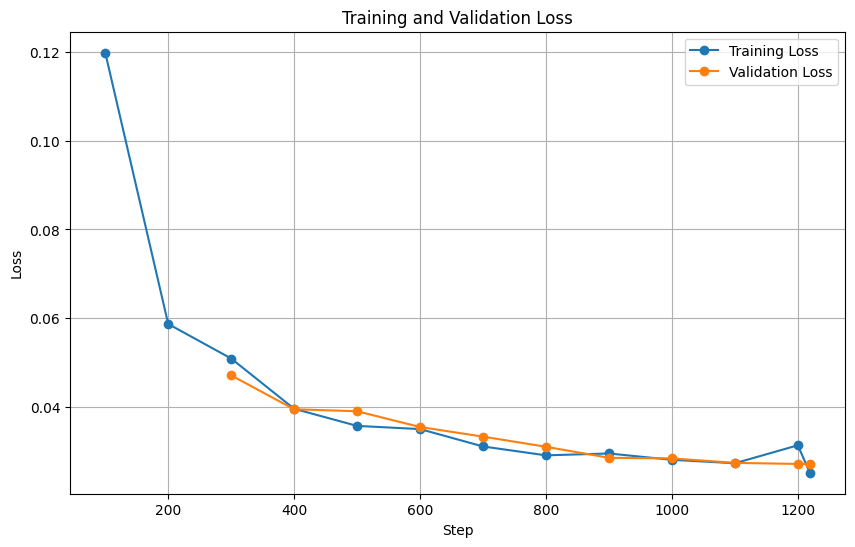

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

data = [
    [100, 0.119830, None],
    [200, 0.058686, None],
    [300, 0.050898, 0.047093],
    [400, 0.039568, 0.039462],
    [500, 0.035710, 0.039008],
    [600, 0.034992, 0.035458],
    [700, 0.031074, 0.033290],
    [800, 0.029071, 0.031002],
    [900, 0.029494, 0.028516],
    [1000, 0.028062, 0.028381],
    [1100, 0.027290, 0.027379],
    [1200, 0.031335, 0.027134],
    [1219, 0.025155, 0.027136],
]

plt.figure(figsize=(10, 6))

plt.plot(
    df["step"],
    df["train_loss"],
    marker="o",
    label="Training Loss"
)

eval_df = df.dropna(subset=["eval_loss"])
plt.plot(
    eval_df["step"],
    eval_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
SAVE_DIR = OUTPUT_DIR / "final_adapter"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

train_info = {
    "base_model": MODEL_ID,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "output_schema": [
        "crop",
        "plant_part",
        "canonical_label",
        "condition_group",
        "visible_symptoms",
        "lesion_location",
        "symptom_pattern",
        "severity_level",
        "confidence_level",
        "triage_level",
        "image_quality",
    ],
    "method": "QLoRA",
    "lora_r": 16,
    "lora_alpha": 32,
    "min_pixels": MIN_PIXELS,
    "max_pixels": MAX_PIXELS,
}

with open(SAVE_DIR / "train_info.json", "w", encoding="utf-8") as f:
    json.dump(train_info, f, ensure_ascii=False, indent=2)

print("Saved adapter to:", SAVE_DIR)

for p in SAVE_DIR.iterdir():
    print("-", p.name)

Saved adapter to: /kaggle/working/qwen25_vl_3b_agri_lora/final_adapter
- adapter_config.json
- README.md
- train_info.json
- tokenizer_config.json
- chat_template.jinja
- adapter_model.safetensors
- processor_config.json
- tokenizer.json


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Image: /kaggle/input/datasets/hoanggiabao3105/dataset/Ca_chua_filtered/Ca_chua_filtered/Tomato___Tomato_Yellow_Leaf_Curl_Virus/a2ad6569-4873-4272-8e53-4e98d949d9e0___YLCV_GCREC 5363.JPG
Ground truth target:
{"crop": "cà chua", "plant_part": "lá", "canonical_label": "bệnh xoăn vàng lá do virus", "condition_group": "viral_disease", "visible_symptoms": "lá non nhỏ, vàng mép/gân lá và cong cuốn lên; cây có thể chùn lại", "lesion_location": "mép lá", "symptom_pattern": "loang khảm/xoăn biến dạng", "severity_level": "trung bình", "confidence_level": "cao", "triage_level": "early_action", "image_quality": "đạt yêu cầu"}

VLM output:
{"crop": "cà chua", "plant_part": "lá", "canonical_label": "khỏe", "condition_group": "healthy", "visible_symptoms": "phiến lá xanh khá đồng đều; chưa thấy nhiều đốm hoại tử, mảng cháy hoặc biến dạng bệnh đặc trưng", "lesion_location": "lá", "symptom_pattern": "chưa thấy triệu chứng bệnh rõ", "severity_level": "chưa thấy tổn thương rõ", "confidence_level": "cao", 

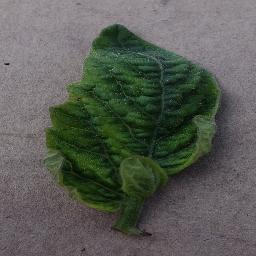

In [14]:
@torch.no_grad()
def vlm_predict_json(image_path, user_question="Lá cây này bị bệnh gì?"):
    model.eval()

    prompt = f"""
Câu hỏi của người dùng:
{user_question}

Hãy quan sát ảnh và trả về JSON với đúng các trường sau:
- crop
- plant_part
- canonical_label
- condition_group
- visible_symptoms
- lesion_location
- symptom_pattern
- severity_level
- confidence_level
- triage_level
- image_quality

Yêu cầu:
- Chỉ trả về JSON.
- Không viết đoạn tư vấn xử lý bệnh.
""".strip()

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": str(image_path),
                },
                {
                    "type": "text",
                    "text": prompt,
                },
            ],
        },
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        temperature=0.0,
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text


sample = val_df.sample(1, random_state=SEED).iloc[0]
test_image = sample["image_path"]

print("Image:", test_image)
print("Ground truth target:")
print(sample["target_json"])

pred = vlm_predict_json(
    test_image,
    user_question="Lá cây này có dấu hiệu như vậy thì là bệnh gì?"
)

print("\nVLM output:")
print(pred)

display(Image.open(test_image).convert("RGB"))

In [15]:
test_samples = val_df.sample(5, random_state=123).reset_index(drop=True)

for i, row in test_samples.iterrows():
    print("=" * 80)
    print("Sample:", i + 1)
    print("Image:", row["image_path"])
    print("GT:", row["target_json"])

    pred = vlm_predict_json(
        row["image_path"],
        user_question="Lá cây này bị gì?"
    )

    print("PRED:", pred)

Sample: 1
Image: /kaggle/input/datasets/hoanggiabao3105/dataset/Dua_leo_filtered/Dua_leo_filtered/Gummy_Stem_Blight/Gummy-Stem-Blight-114-_jpg.rf.1d1049433b34e70304f850e688eb02c0.jpg
GT: {"crop": "dưa leo", "plant_part": "lá", "canonical_label": "bệnh chảy gôm thân", "condition_group": "bệnh nấm", "visible_symptoms": "nhiều vết nâu/cháy lá lan rộng, cần kiểm tra thân ngay, vùng vàng khá nổi bật, mô nâu/cháy chiếm khá nhiều", "lesion_location": "thân/lá", "symptom_pattern": "vết bệnh thân/lá", "severity_level": "nặng", "confidence_level": "cao", "triage_level": "urgent_action", "image_quality": "đạt yêu cầu"}
PRED: {"crop": "dưa leo", "plant_part": "lá", "canonical_label": "bệnh chảy gôm thân", "condition_group": "bệnh nấm", "visible_symptoms": "vết cháy nâu ở mép hoặc giữa gân lá, cần đối chiếu thêm thân/gốc, vùng vàng khá nổi bật, phần lá xanh vẫn còn tương đối nhiều", "lesion_location": "thân/lá", "symptom_pattern": "vết bệnh thân/lá", "severity_level": "trung bình", "confidence_leve

In [16]:
import shutil

zip_path = "/kaggle/working/qwen25_vl_3b_agri_lora_adapter.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/kaggle/working/qwen25_vl_3b_agri_lora_adapter",
    format="zip",
    root_dir=str(SAVE_DIR)
)

print("ZIP:", zip_path)
print("Size MB:", os.path.getsize(zip_path) / 1024 / 1024)

ZIP: /kaggle/working/qwen25_vl_3b_agri_lora_adapter.zip
Size MB: 133.2887668609619
